In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import os

In [8]:
# load in large basis set results first
dt = 0.05
delayrange = np.arange(5,555,50)
delayau = dt*delayrange

In [9]:
molecules = ['heh+','h2']
bases = ['sto-3g','6-31g','6-31gss']

gaplookup = {}
freqlookup = {}

mygaps = [(0,1),(0,2),(1,2),(0,3),(1,3),(2,3)]
allgapstr = []
for gap in mygaps:
    gapstr = "E"+str(gap[1])+"-E"+str(gap[0])+""
    allgapstr.append(gapstr)

print(allgapstr)

for mol in molecules:
    for basis in bases:
        fname = './psi4data/fci_' + mol + '_' + basis + '.npz'
        datfile = np.load(fname)
        h0 = datfile['ham']
        for gap in mygaps:
            freq = np.round((h0[gap[1]]-h0[gap[0]])/(2*np.pi),6)
            freqstr = str(freq)
            while len(freqstr) < 8:
                freqstr += "0"
            gapstr = "E"+str(gap[1])+"-E"+str(gap[0])+""
            gaplookup[(mol,basis,freqstr)] = gapstr
            freqlookup[(mol,basis,gapstr)] = freqstr
            # print("(E"+str(gap[1])+" - E"+str(gap[0])+")/(2 pi) = " + freqstr)

['E1-E0', 'E2-E0', 'E2-E1', 'E3-E0', 'E3-E1', 'E3-E2']


In [11]:
freqlookup['heh+','6-31gss','E1-E0']

'0.127827'

In [6]:
# h2 in 6-31g, I did E1-E0 = 0.062828
#                    E2-E0 = 0.089540
#                    E3-E2 = 0.047314
#                    E3-E0 = 0.136854
#                    E3-E1 = 0.074027
# not yet:
#                    E2-E1 = 0.026712

In [7]:
# heh+ in 6-31g, I did E1-E0 = 0.125766
#                      E2-E0 = 0.154105
#                      E2-E1 = 0.028338
#                      E3-E0 = 0.241404
#                      E3-E1 = 0.115638
# in perlgpu directory:
#                      E3-E2 = 0.087299

In [8]:
gaplookup['heh+','6-31g','0.028338']

'E2-E1'

In [9]:
# large basis set results
lbsr = np.zeros((2, 6, 11))
for i in range(2):
    mol = molecules[i]
    for j in range(6):
        freq = freqlookup[mol, '6-31gss', allgapstr[j]]
        for k in range(11):
            delay = 5 + 50*k
            fname = 'fci_' + mol + '_6-31gss_0.050000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
            x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
            lbsr[i, j, k] = x[1]

In [10]:
# medium basis set results
dt = 0.01
delayrangeH2 = np.arange(5,955+5,50)
print(delayrangeH2)
delayauH2 = dt*delayrangeH2
mbsrH2 = np.zeros((6, 20))
delayrangeHeH = np.arange(5,455+5,50)
print(delayrangeHeH)
delayauHeH = dt*delayrangeHeH
mbsrHeH = np.zeros((6, 10))

[  5  55 105 155 205 255 305 355 405 455 505 555 605 655 705 755 805 855
 905 955]
[  5  55 105 155 205 255 305 355 405 455]


In [11]:
# load in mbsrH2
for j in range(6):
    gapstr = allgapstr[j]
    if gapstr=='E2-E1':    # this one is in progress
        continue   
    freq = freqlookup['h2', '6-31g', gapstr]
    fname = 'fci_h2_6-31g_0.010000_' + freq + '_0.100000_5.txt'
    x = np.loadtxt('./perlresults/'+fname, skiprows=3, delimiter=',')
    mbsrH2[j, :] = x[:, 1]

# load in mbsrHeH
for j in range(6):
    gapstr = allgapstr[j]
    if gapstr=='E3-E2':    # this one is in perlgpu
        continue   
    freq = freqlookup['heh+', '6-31g', gapstr]
    fname = 'fci_heh+_6-31g_0.010000_' + freq + '_0.100000_5.txt'
    x = np.loadtxt('./perlresults/'+fname, skiprows=3, delimiter=',')
    mbsrHeH[j, :] = x[:, 1]

In [12]:
lastfreq = freqlookup['heh+', '6-31g', 'E3-E2']
j = allgapstr.index('E3-E2')
for i in range(10):
    fname = 'fci_heh+_6-31g_0.010000_' + str(delayrangeHeH[i]) + '_' + lastfreq + '_0.100000_5.txt'
    x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
    mbsrHeH[j, i] = x[1]

In [13]:
# small basis set results
dt = 0.01
delaysmallH2 = np.arange(40,440,40)
print(delaysmallH2)
delaysmallauH2 = dt*delaysmallH2
sbsrH2 = np.zeros((6, 10))
delaysmallHeH = np.arange(5,105,5)
print(delaysmallHeH)
delaysmallauHeH = dt*delaysmallHeH
sbsrHeH = np.zeros((6, 20))

[ 40  80 120 160 200 240 280 320 360 400]
[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100]


In [14]:
# small basis set results
i=0 # heh+
mol = molecules[i]
for j in range(6):
    freq = freqlookup[mol, 'sto-3g', allgapstr[j]]
    for k in range(20):
        delay = delaysmallHeH[k]
        fname = 'fci_' + mol + '_sto-3g_0.010000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
        sbsrHeH[j, k] = x[1]

i=1 # h2
mol = molecules[i]
for j in range(6):
    freq = freqlookup[mol, 'sto-3g', allgapstr[j]]
    for k in range(10):
        delay = delaysmallH2[k]
        fname = 'fci_' + mol + '_sto-3g_0.010000_' + str(delay) + '_' + freq + '_0.100000_5.txt'
        x = np.loadtxt('./perlgpu/'+fname, skiprows=2, delimiter=',')
        sbsrH2[j, k] = x[1]

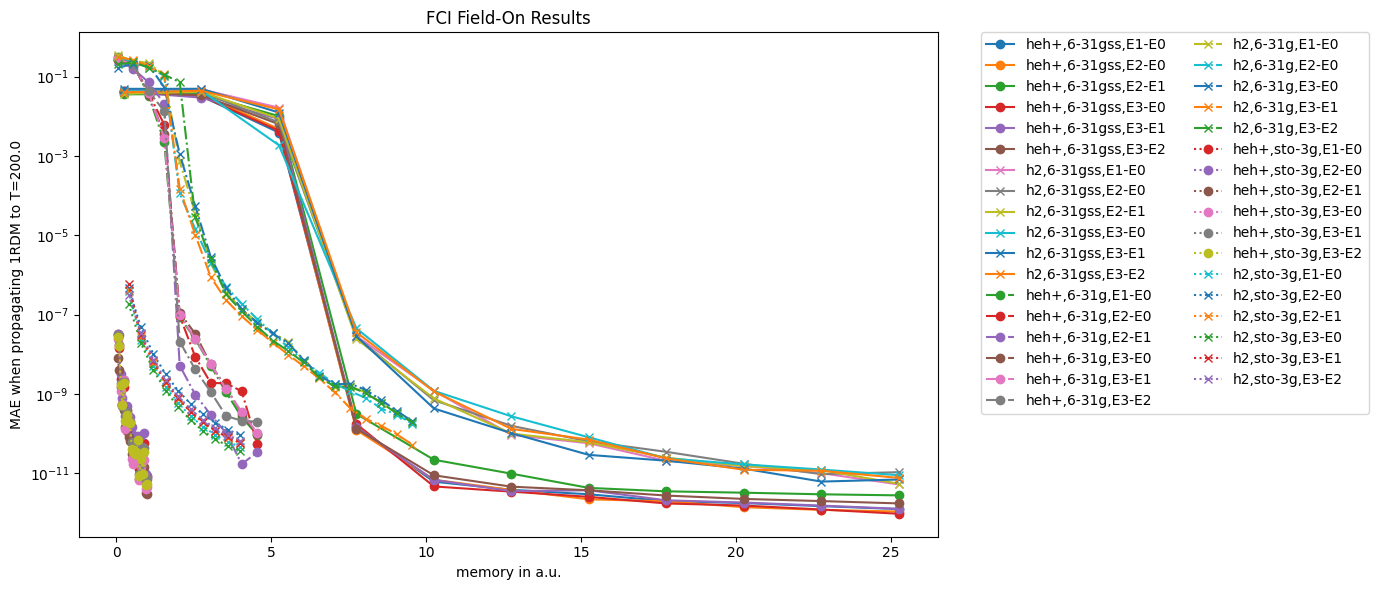

In [20]:
plt.figure(figsize=(14, 6))

for i in range(2):
    mol = molecules[i]
    for j in range(6):
        freq = freqlookup[mol, '6-31gss', allgapstr[j]]
        if mol=='h2':
            mrk = 'x'
            ls = '-'
        else:
            mrk = 'o'
            ls = '-'
        plt.semilogy(delayau, lbsr[i, j, :], 
                     label=mol+',6-31gss,'+gaplookup[mol,'6-31gss',freq], 
                     marker=mrk, linestyle=ls)

for i in range(2):
    mol = molecules[i]
    for j in range(6):
        freq = freqlookup[mol, '6-31g', allgapstr[j]]
        if mol=='h2':
            mrk = 'x'
            ls = '-.'
            if allgapstr[j]=='E2-E1':
                continue
            plt.semilogy(delayauH2, mbsrH2[j, :], 
                         label=mol+',6-31g,'+gaplookup[mol,'6-31g',freq], 
                         marker=mrk, linestyle=ls)
        else:
            mrk = 'o'
            ls = '-.'
            if j==5:
                plt.semilogy(delayauHeH[1:], mbsrHeH[j, 1:], 
                             label=mol+',6-31g,'+gaplookup[mol,'6-31g',freq], 
                             marker=mrk, linestyle=ls)            
            else:
                plt.semilogy(delayauHeH, mbsrHeH[j, :], 
                             label=mol+',6-31g,'+gaplookup[mol,'6-31g',freq], 
                             marker=mrk, linestyle=ls)

for i in range(2):
    mol = molecules[i]
    for j in range(6):
        freq = freqlookup[mol, 'sto-3g', allgapstr[j]]
        if mol=='h2':
            mrk = 'x'
            ls = ':'
            plt.semilogy(delaysmallauH2, sbsrH2[j, :], 
                         label=mol+',sto-3g,'+gaplookup[mol,'sto-3g',freq], 
                         marker=mrk, linestyle=ls)
        else:
            mrk = 'o'
            ls = ':'
            plt.semilogy(delaysmallauHeH, sbsrHeH[j, :], 
                         label=mol+',sto-3g,'+gaplookup[mol,'sto-3g',freq], 
                         marker=mrk, linestyle=ls)            

plt.xlabel('memory in a.u.')
plt.ylabel('MAE when propagating 1RDM to T=200.0')
plt.title('FCI Field-On Results')
plt.legend(loc="upper left", ncol=2, bbox_to_anchor=(1.05, 1), borderaxespad=0)
plt.tight_layout()
plt.show()